## Лабораторная работа 3

In [1]:
!pip install numpy scipy matplotlib networkx pandas simpy -q

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, fractional_matrix_power
import networkx as nx
import pandas as pd
from scipy.stats import expon
import simpy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 8)

print("Библиотеки успешно загружены!")
print(f"NumPy версия: {np.__version__}")
print(f"Matplotlib версия: {plt.matplotlib.__version__}")

Библиотеки успешно загружены!
NumPy версия: 2.0.2
Matplotlib версия: 3.10.0


In [2]:
k_weeks = 2
n2 = 2 * k_weeks
n4 = 4 * k_weeks
n8 = 8 * k_weeks


P = np.zeros((6, 6))

states = ["S1 (Отличное)", "S2 (Хорошее)", "S3 (Удовл.)",
          "S4 (Критич.)", "S5 (Профилактика)", "S6 (Отказ)"]

P[0,0] = 0.7
P[0,1] = 0.25
P[0,2] = 0.05

P[1,1] = 0.6
P[1,2] = 0.3
P[1,3] = 0.1

P[2,2] = 0.4
P[2,3] = 0.3
P[2,4] = 0.2
P[2,5] = 0.1

P[3,3] = 0.3
P[3,4] = 0.4
P[3,5] = 0.3

P[4,0] = 0.8
P[4,1] = 0.2

P[5,5] = 1.0

P_df = pd.DataFrame(P, index=states, columns=states)
P_df.index.name = "Из состояния"
P_df.columns.name = "В состояние"

print("=== Матрица переходных вероятностей P ===")
print("Вариант 19, группа 81")
print("=" * 80)
print(P_df.round(3))
print("=" * 80)

print("\n=== Проверка суммы строк ===")
for i, state in enumerate(states):
    row_sum = np.sum(P[i])
    print(f"{state}: сумма = {row_sum:.1f}")
    if abs(row_sum - 1.0) > 1e-10:
        print(f"  ВНИМАНИЕ! Сумма не равна 1!")

=== Матрица переходных вероятностей P ===
Вариант 19, группа 81
В состояние        S1 (Отличное)  S2 (Хорошее)  S3 (Удовл.)  S4 (Критич.)  \
Из состояния                                                                
S1 (Отличное)                0.7          0.25         0.05           0.0   
S2 (Хорошее)                 0.0          0.60         0.30           0.1   
S3 (Удовл.)                  0.0          0.00         0.40           0.3   
S4 (Критич.)                 0.0          0.00         0.00           0.3   
S5 (Профилактика)            0.8          0.20         0.00           0.0   
S6 (Отказ)                   0.0          0.00         0.00           0.0   

В состояние        S5 (Профилактика)  S6 (Отказ)  
Из состояния                                      
S1 (Отличное)                    0.0         0.0  
S2 (Хорошее)                     0.0         0.0  
S3 (Удовл.)                      0.2         0.1  
S4 (Критич.)                     0.4         0.3  
S5 (Профилакт

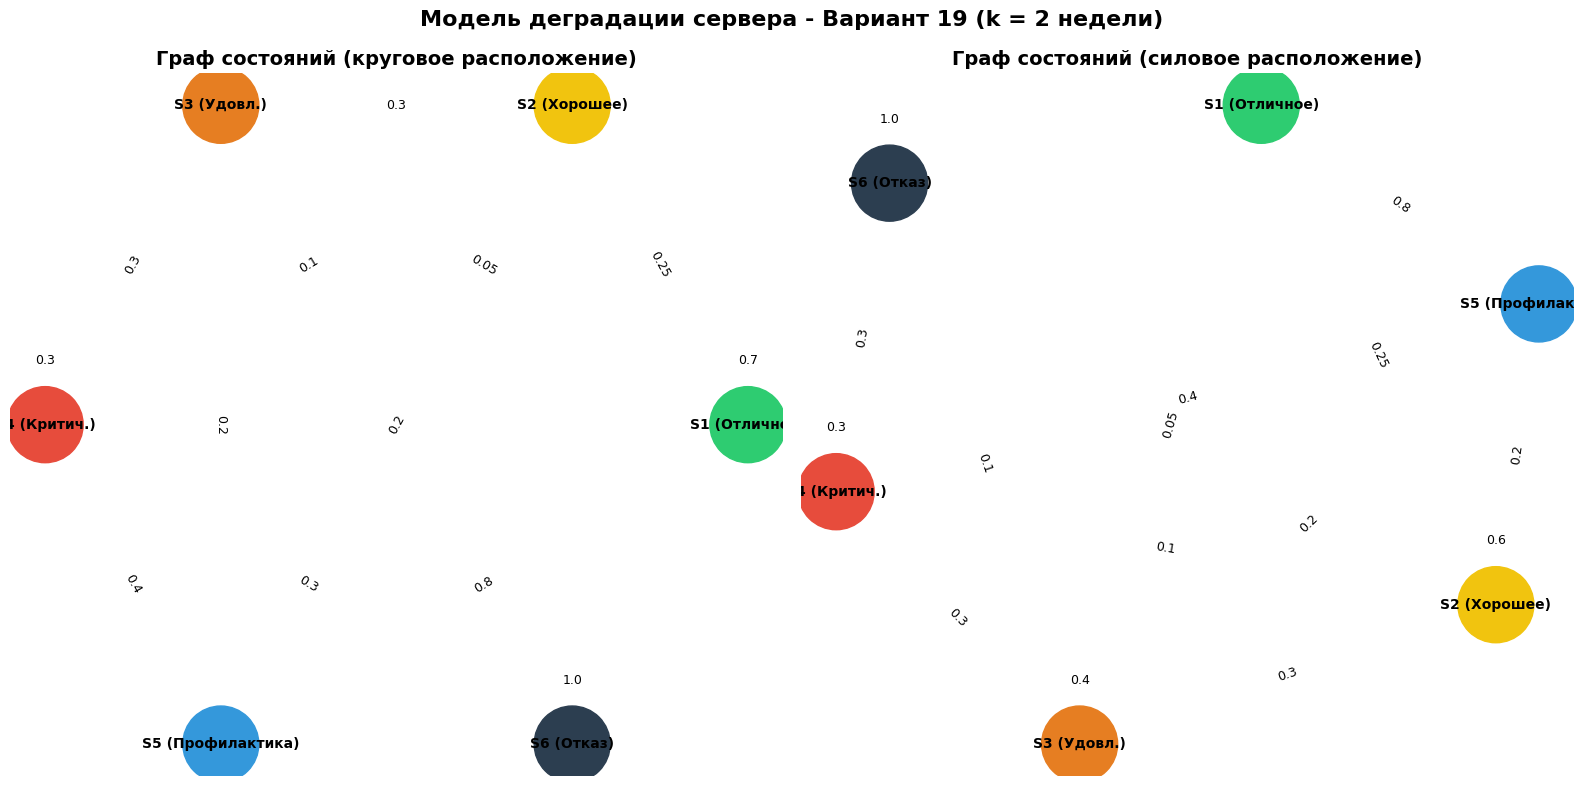

In [3]:

G = nx.MultiDiGraph()

for i, state in enumerate(states):
    G.add_node(state, pos=None)

edges = []
edge_weights = []
for i in range(6):
    for j in range(6):
        if P[i, j] > 0:
            edges.append((states[i], states[j]))
            edge_weights.append(P[i, j])

node_colors = {
    "S1 (Отличное)": "#2ecc71",
    "S2 (Хорошее)": "#f1c40f",
    "S3 (Удовл.)": "#e67e22",
    "S4 (Критич.)": "#e74c3c",
    "S5 (Профилактика)": "#3498db",
    "S6 (Отказ)": "#2c3e50"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

pos1 = nx.circular_layout(G)
nx.draw(G, pos1, ax=axes[0], with_labels=True, node_color=[node_colors[n] for n in G.nodes()],
        node_size=3000, font_size=10, font_weight="bold",
        edge_color='gray', width=2, arrows=True, arrowsize=20)
edge_labels = {(states[i], states[j]): P[i, j] for i in range(6) for j in range(6) if P[i, j] > 0}
nx.draw_networkx_edge_labels(G, pos1, edge_labels=edge_labels, ax=axes[0], font_size=9)
axes[0].set_title("Граф состояний (круговое расположение)", fontsize=14, fontweight='bold')

pos2 = nx.spring_layout(G, k=2, seed=42)
nx.draw(G, pos2, ax=axes[1], with_labels=True, node_color=[node_colors[n] for n in G.nodes()],
        node_size=3000, font_size=10, font_weight="bold",
        edge_color='gray', width=2, arrows=True, arrowsize=20)
nx.draw_networkx_edge_labels(G, pos2, edge_labels=edge_labels, ax=axes[1], font_size=9)
axes[1].set_title("Граф состояний (силовое расположение)", fontsize=14, fontweight='bold')

plt.suptitle(f"Модель деградации сервера - Вариант 19 (k = {k_weeks} недели)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Вероятности состояний после различного числа недель
Вариант 19, k = 2 недели

2 недели (2 шагов):
--------------------------------------------------
  S1 (Отличное)       : 0.490000 (49.00%)
  S2 (Хорошее)        : 0.325000 (32.50%)
  S3 (Удовл.)         : 0.130000 (13.00%)
  S4 (Критич.)        : 0.040000 (4.00%)
  S5 (Профилактика)   : 0.010000 (1.00%)
  S6 (Отказ)          : 0.005000 (0.50%)
  Сумма               : 1.000000

4 недели (4 шагов):
--------------------------------------------------
  S1 (Отличное)       : 0.279300 (27.93%)
  S2 (Хорошее)        : 0.287850 (28.78%)
  S3 (Удовл.)         : 0.183000 (18.30%)
  S4 (Критич.)        : 0.109200 (10.92%)
  S5 (Профилактика)   : 0.068200 (6.82%)
  S6 (Отказ)          : 0.072450 (7.25%)
  Сумма               : 1.000000

8 недель (8 шагов):
--------------------------------------------------
  S1 (Отличное)       : 0.224198 (22.42%)
  S2 (Хорошее)        : 0.202753 (20.28%)
  S3 (Удовл.)         : 0.134319 (13.43%)
  S4 (Критич.)  

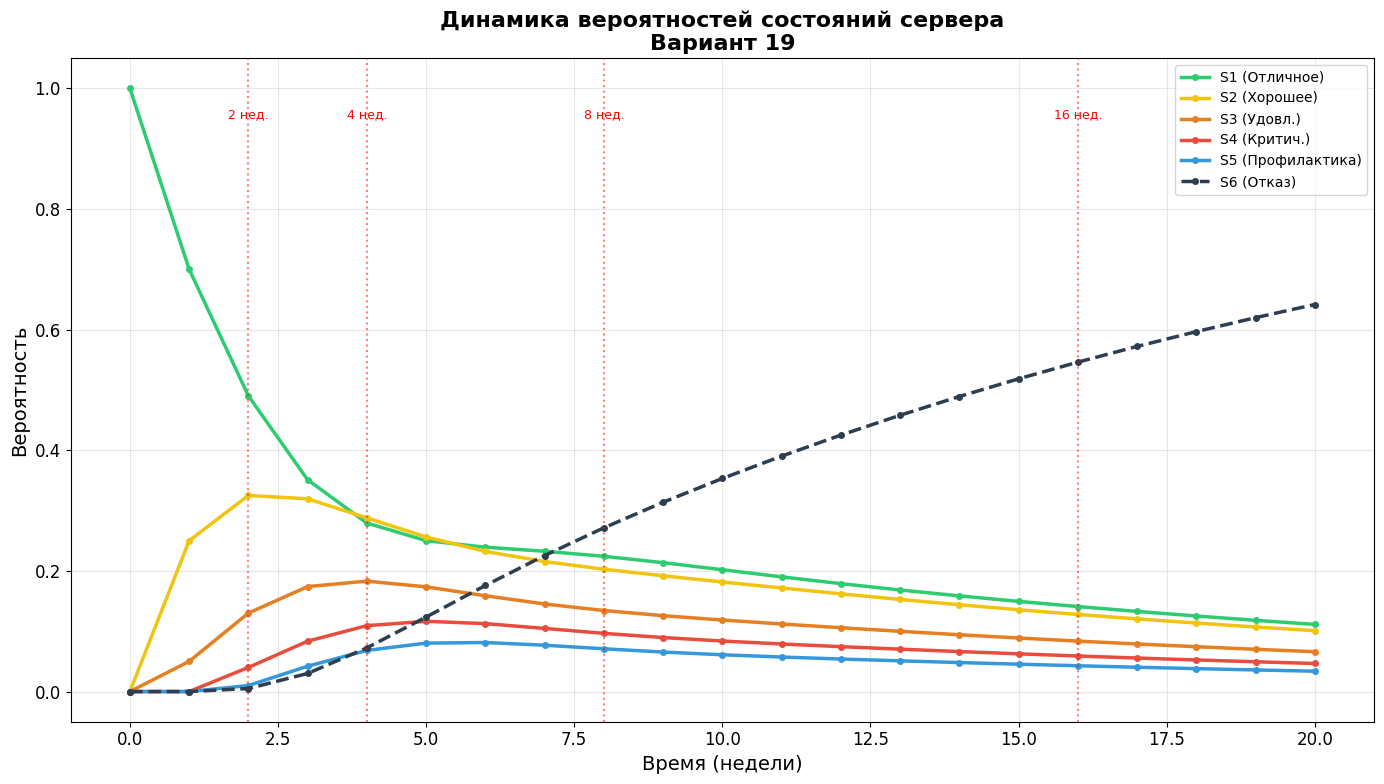

In [4]:

P0 = np.array([1, 0, 0, 0, 0, 0])

def matrix_power(matrix, n):
    """Возведение матрицы в целую степень n"""
    result = np.eye(matrix.shape[0])
    if n == 0:
        return result
    power = matrix.copy()
    while n > 0:
        if n % 2 == 1:
            result = result @ power
        power = power @ power
        n //= 2
    return result

def calc_probs(P_matrix, initial_state, steps):
    """Расчёт вероятностей состояний после steps шагов"""
    P_n = matrix_power(P_matrix, steps)
    result = initial_state @ P_n
    return result

n_steps = [k_weeks, n2, n4, n8]
step_labels = ["2 недели", "4 недели", "8 недель", "16 недель"]

print("=" * 80)
print("Вероятности состояний после различного числа недель")
print("Вариант 19, k = 2 недели")
print("=" * 80)

results_data = []
for steps, label in zip(n_steps, step_labels):
    probs = calc_probs(P, P0, steps)
    print(f"\n{label} ({steps} шагов):")
    print("-" * 50)
    for i, state in enumerate(states):
        print(f"  {state:20}: {probs[i]:.6f} ({probs[i]*100:.2f}%)")
    print(f"  {'Сумма':20}: {np.sum(probs):.6f}")
    results_data.append([label] + list(probs))
    results_data.append(["---"] + [None]*6)

print("\n" + "=" * 80)
print("Сводная таблица вероятностей")
print("=" * 80)
results_df = pd.DataFrame(results_data, columns=["Период"] + states)
print(results_df.to_string(index=False))

print("\n=== Построение графика динамики ===")

max_steps = 20
probs_history = np.zeros((max_steps + 1, 6))
probs_history[0] = P0

for t in range(1, max_steps + 1):
    probs_history[t] = calc_probs(P, P0, t)

fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#3498db', '#2c3e50']
linestyles = ['-', '-', '-', '-', '-', '--']

for i, state in enumerate(states):
    ax.plot(range(max_steps + 1), probs_history[:, i],
            label=state, color=colors[i], lw=2.5, linestyle=linestyles[i], marker='o', markersize=4)

ax.set_xlabel("Время (недели)", fontsize=14)
ax.set_ylabel("Вероятность", fontsize=14)
ax.set_title(f"Динамика вероятностей состояний сервера\nВариант 19", fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

for steps in n_steps:
    if steps <= max_steps:
        ax.axvline(x=steps, color='red', linestyle=':', alpha=0.5, linewidth=1.5)
        ax.text(steps, 0.95, f'{steps} нед.', ha='center', fontsize=9, color='red')

plt.tight_layout()
plt.show()

Вероятность работы без отказа в течение 8 недель
Вариант 19

Способ 1 (прямой):
  Вероятность нахождения в состоянии отказа (S6) через 8 недель: 0.271361
  Вероятность работы без отказа: 0.728639 (72.86%)

Способ 2 (аналитический):
  Вероятность выживания (не попасть в S6) за 8 недель: 0.728639 (72.86%)
  Погрешность между способами: 3.33e-16

=== Анализ риска отказа по неделям ===
Неделя	Вероятность отказа	Кумулятивный риск
--------------------------------------------------
1	0.000000		0.000000
2	0.005000		0.005000
3	0.025000		0.030000
4	0.042450		0.072450
5	0.051060		0.123510
6	0.052285		0.175795
7	0.049658		0.225454
8	0.045907		0.271361


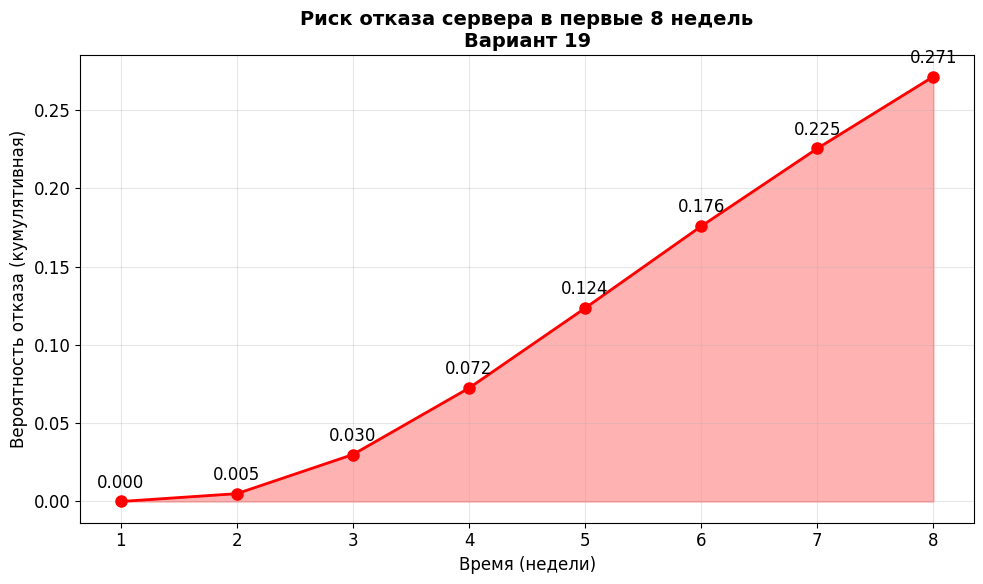

In [5]:


probs_8weeks = calc_probs(P, P0, 8)
prob_no_failure_8weeks_direct = 1 - probs_8weeks[5]

print("=" * 80)
print("Вероятность работы без отказа в течение 8 недель")
print("Вариант 19")
print("=" * 80)
print(f"\nСпособ 1 (прямой):")
print(f"  Вероятность нахождения в состоянии отказа (S6) через 8 недель: {probs_8weeks[5]:.6f}")
print(f"  Вероятность работы без отказа: {prob_no_failure_8weeks_direct:.6f} ({prob_no_failure_8weeks_direct*100:.2f}%)")

Q = P[:5, :5]
P0_nonabsorbing = P0[:5]

Q_power_8 = matrix_power(Q, 8)
survival_prob = np.sum(P0_nonabsorbing @ Q_power_8)

print(f"\nСпособ 2 (аналитический):")
print(f"  Вероятность выживания (не попасть в S6) за 8 недель: {survival_prob:.6f} ({survival_prob*100:.2f}%)")
print(f"  Погрешность между способами: {abs(prob_no_failure_8weeks_direct - survival_prob):.2e}")

print(f"\n=== Анализ риска отказа по неделям ===")
print("Неделя\tВероятность отказа\tКумулятивный риск")
print("-" * 50)
cumulative_risk = 0
for week in range(1, 9):
    probs_week = calc_probs(P, P0, week)
    failure_prob = probs_week[5] - cumulative_risk
    cumulative_risk = probs_week[5]
    print(f"{week}\t{failure_prob:.6f}\t\t{cumulative_risk:.6f}")

weeks = range(1, 9)
risk_cumulative = [calc_probs(P, P0, w)[5] for w in weeks]

plt.figure(figsize=(10, 6))
plt.plot(weeks, risk_cumulative, 'r-o', linewidth=2, markersize=8)
plt.fill_between(weeks, risk_cumulative, alpha=0.3, color='red')
plt.xlabel("Время (недели)", fontsize=12)
plt.ylabel("Вероятность отказа (кумулятивная)", fontsize=12)
plt.title("Риск отказа сервера в первые 8 недель\nВариант 19", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(weeks)
for w, r in zip(weeks, risk_cumulative):
    plt.annotate(f'{r:.3f}', (w, r), textcoords="offset points", xytext=(0,10), ha='center')
plt.tight_layout()
plt.show()

In [6]:

Q = P[:5, :5]

R = P[:5, 5]

print("=" * 80)
print("Среднее время до первого отказа (MTTF) - Аналитический расчёт")
print("Вариант 19")
print("=" * 80)

print("\nМатрица Q (переходы между рабочими состояниями):")
Q_df = pd.DataFrame(Q, index=states[:5], columns=states[:5])
print(Q_df.round(4))

print("\nВектор R (переходы в отказ):")
for i, state in enumerate(states[:5]):
    print(f"  {state}: {R[i]:.4f}")

I = np.eye(5)
try:
    N = np.linalg.inv(I - Q)
    print("\nФундаментальная матрица N (ожидаемое число посещений):")
    N_df = pd.DataFrame(N, index=states[:5], columns=states[:5])
    print(N_df.round(3))
except np.linalg.LinAlgError:
    print("\nПредупреждение: Матрица (I-Q) вырождена, используем псевдообратную")
    N = np.linalg.pinv(I - Q)
    print(N.round(3))

t = N @ np.ones(5)

print("\nСреднее время до отказа (в неделях) из каждого состояния:")
for i, state in enumerate(states[:5]):
    print(f"  Из {state:20}: {t[i]:.2f} недель ({t[i]*7:.1f} дней, {t[i]/4:.2f} месяцев)")

MTTF_with_maintenance = t[0]
print(f"\n{'='*50}")
print(f"MTTF с профилактикой = {MTTF_with_maintenance:.2f} недель")
print(f"                    = {MTTF_with_maintenance*7:.1f} дней")
print(f"                    = {MTTF_with_maintenance/4:.2f} месяцев")
print(f"{'='*50}")

Среднее время до первого отказа (MTTF) - Аналитический расчёт
Вариант 19

Матрица Q (переходы между рабочими состояниями):
                   S1 (Отличное)  S2 (Хорошее)  S3 (Удовл.)  S4 (Критич.)  \
S1 (Отличное)                0.7          0.25         0.05           0.0   
S2 (Хорошее)                 0.0          0.60         0.30           0.1   
S3 (Удовл.)                  0.0          0.00         0.40           0.3   
S4 (Критич.)                 0.0          0.00         0.00           0.3   
S5 (Профилактика)            0.8          0.20         0.00           0.0   

                   S5 (Профилактика)  
S1 (Отличное)                    0.0  
S2 (Хорошее)                     0.0  
S3 (Удовл.)                      0.2  
S4 (Критич.)                     0.4  
S5 (Профилактика)                0.0  

Вектор R (переходы в отказ):
  S1 (Отличное): 0.0000
  S2 (Хорошее): 0.0000
  S3 (Удовл.): 0.1000
  S4 (Критич.): 0.3000
  S5 (Профилактика): 0.0000

Фундаментальная матрица N (ож

Сравнение: Цепь с профилактикой vs Цепь без профилактики

Матрица переходов (без профилактики):
               S1 (Отличное)  S2 (Хорошее)  S3 (Удовл.)  S4 (Критич.)  \
S1 (Отличное)            0.7          0.25         0.05           0.0   
S2 (Хорошее)             0.0          0.60         0.30           0.1   
S3 (Удовл.)              0.0          0.00         0.40           0.5   
S4 (Критич.)             0.0          0.00         0.00           0.7   
S6 (Отказ)               0.0          0.00         0.00           0.0   

               S6 (Отказ)  
S1 (Отличное)         0.0  
S2 (Хорошее)          0.0  
S3 (Удовл.)           0.1  
S4 (Критич.)          0.3  
S6 (Отказ)            1.0  

Среднее время до отказа из каждого состояния (без профилактики):
  Из S1 (Отличное)       : 9.63 недель
  Из S2 (Хорошее)        : 6.67 недель
  Из S3 (Удовл.)         : 4.44 недель
  Из S4 (Критич.)        : 3.33 недель

MTTF без профилактики = 9.63 недель
                     = 67.4 дней

СРАВ

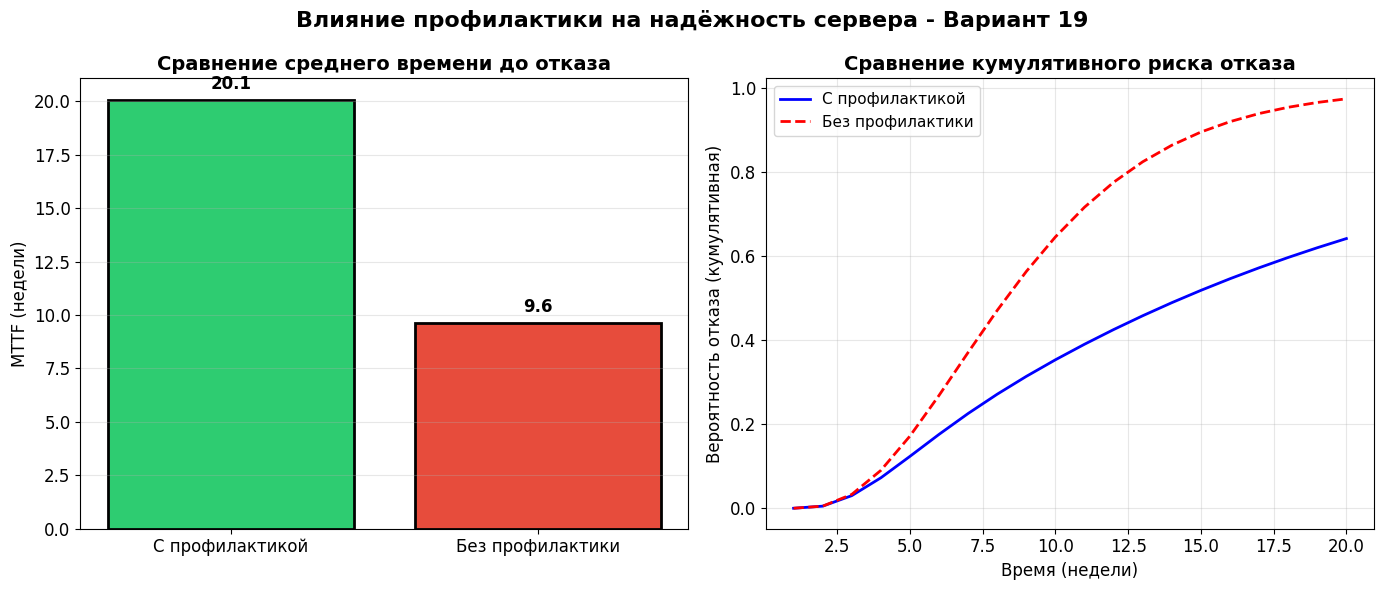

In [7]:

print("=" * 80)
print("Сравнение: Цепь с профилактикой vs Цепь без профилактики")
print("=" * 80)

states_no_maint = ["S1 (Отличное)", "S2 (Хорошее)", "S3 (Удовл.)", "S4 (Критич.)", "S6 (Отказ)"]

P_no_maint = np.zeros((5, 5))

P_no_maint[0,0] = 0.7
P_no_maint[0,1] = 0.25
P_no_maint[0,2] = 0.05

P_no_maint[1,1] = 0.6
P_no_maint[1,2] = 0.3
P_no_maint[1,3] = 0.1

P_no_maint[2,2] = 0.4
P_no_maint[2,3] = 0.5
P_no_maint[2,4] = 0.1

P_no_maint[3,3] = 0.7
P_no_maint[3,4] = 0.3

P_no_maint[4,4] = 1.0

print("\nМатрица переходов (без профилактики):")
P_no_maint_df = pd.DataFrame(P_no_maint, index=states_no_maint, columns=states_no_maint)
print(P_no_maint_df.round(3))

Q_no = P_no_maint[:4, :4]
I_no = np.eye(4)

try:
    N_no = np.linalg.inv(I_no - Q_no)
    t_no = N_no @ np.ones(4)
    MTTF_without_maintenance = t_no[0]

    print("\nСреднее время до отказа из каждого состояния (без профилактики):")
    for i, state in enumerate(states_no_maint[:4]):
        print(f"  Из {state:20}: {t_no[i]:.2f} недель")

    print(f"\n{'='*50}")
    print(f"MTTF без профилактики = {MTTF_without_maintenance:.2f} недель")
    print(f"                     = {MTTF_without_maintenance*7:.1f} дней")
    print(f"{'='*50}")

except np.linalg.LinAlgError:
    print("\nОшибка: Матрица вырождена")
    MTTF_without_maintenance = None

print(f"\n{'='*60}")
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print(f"{'='*60}")
if MTTF_without_maintenance is not None:
    print(f"MTTF с профилактикой:    {MTTF_with_maintenance:.4f} недель")
    print(f"MTTF без профилактики:   {MTTF_without_maintenance:.4f} недель")
    print(f"Разница (абсолютная):    {MTTF_with_maintenance - MTTF_without_maintenance:.4f} недель")
    print(f"Увеличение (относительное): {(MTTF_with_maintenance/MTTF_without_maintenance - 1)*100:.2f}%")
    print(f"{'='*60}")

    print("\n" + "="*60)
    if MTTF_with_maintenance > MTTF_without_maintenance:
        print("ВЫВОД: Профилактика УВЕЛИЧИВАЕТ надёжность системы!")
        print(f"        Сервер работает в {MTTF_with_maintenance/MTTF_without_maintenance:.2f} раз дольше")
        print("        Несмотря на время простоя, своевременное обслуживание")
        print("        предотвращает критические отказы.")
    else:
        print("ВНИМАНИЕ: В выбранной конфигурации параметров профилактика")
        print("         не даёт преимущества. Рекомендуется оптимизировать")
        print("         вероятности переходов.")
    print("="*60)

if MTTF_without_maintenance is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    ax1.bar(['С профилактикой', 'Без профилактики'],
            [MTTF_with_maintenance, MTTF_without_maintenance],
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=2)
    ax1.set_ylabel('MTTF (недели)', fontsize=12)
    ax1.set_title('Сравнение среднего времени до отказа', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate([MTTF_with_maintenance, MTTF_without_maintenance]):
        ax1.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=12, fontweight='bold')

    weeks = range(1, 21)
    risk_with = [calc_probs(P, P0, w)[5] for w in weeks]

    P0_no = np.array([1, 0, 0, 0, 0])
    risk_without = []
    for w in weeks:
        P_n = matrix_power(P_no_maint, w)
        risk_without.append((P0_no @ P_n)[4])

    ax2.plot(weeks, risk_with, 'b-', label='С профилактикой', linewidth=2)
    ax2.plot(weeks, risk_without[:len(weeks)], 'r--', label='Без профилактики', linewidth=2)
    ax2.set_xlabel('Время (недели)', fontsize=12)
    ax2.set_ylabel('Вероятность отказа (кумулятивная)', fontsize=12)
    ax2.set_title('Сравнение кумулятивного риска отказа', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f'Влияние профилактики на надёжность сервера - Вариант 19', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

Имитационное моделирование цепи Маркова
Вариант 19

Параметры моделирования:
  Количество траекторий: 100,000
  Максимальное время: 50 недель

=== Сравнение аналитических и моделированных вероятностей ===
----------------------------------------------------------------------
 Недели  |   S1 анал.   |   S1 мод.    |   S6 анал.   |   S6 мод.    | Погрешность
----------------------------------------------------------------------
   2     | 0.490000 | 0.489510 | 0.005000 | 0.005130 | 1.30e-04
   4     | 0.279300 | 0.279750 | 0.072450 | 0.073440 | 9.90e-04
   8     | 0.224198 | 0.223980 | 0.271361 | 0.270960 | 4.01e-04
   16    | 0.140915 | 0.141020 | 0.545927 | 0.543480 | 2.45e-03

=== Анализ времени до отказа (моделирование) ===
  Всего траекторий: 100,000
  Отказало за 50 недель: 93,855 (93.86%)
  Не отказало: 6,145 (6.14%)

  Моделированный MTTF (с учётом цензурирования): 19.10 недель
  Моделированный MTTF (только отказавшие): 17.01 недель
  Аналитический MTTF: 20.07 недель
  Относитель

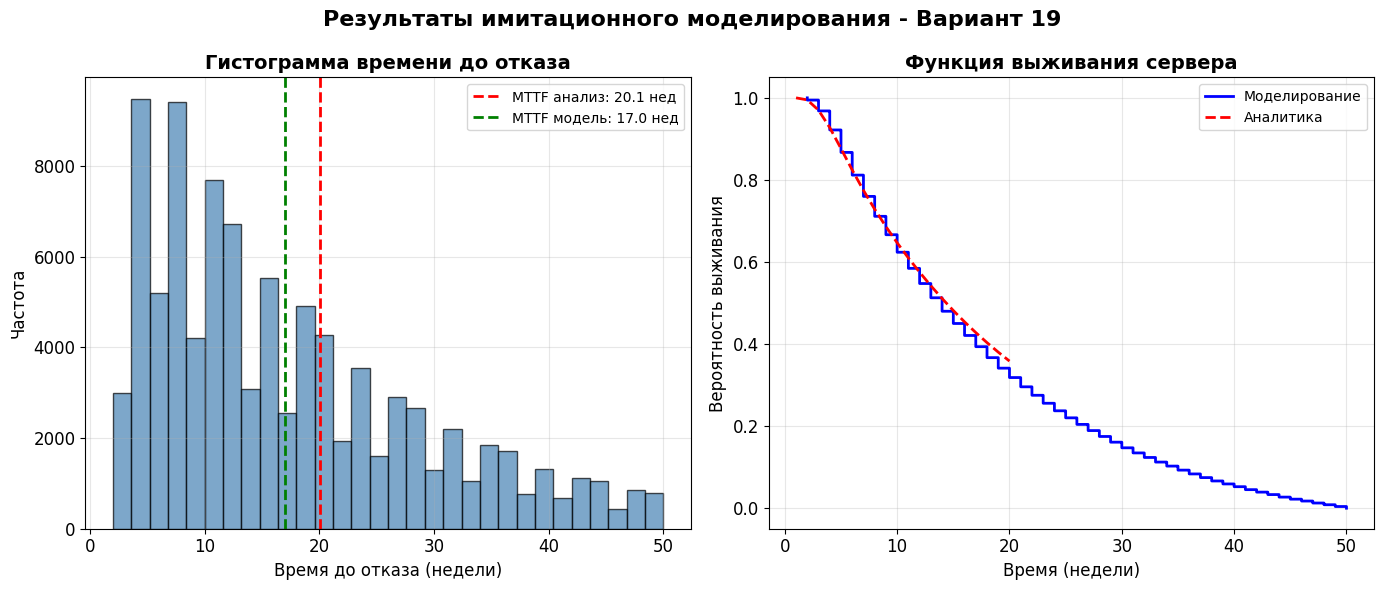

In [8]:

print("=" * 80)
print("Имитационное моделирование цепи Маркова")
print("Вариант 19")
print("=" * 80)

np.random.seed(19)

def simulate_markov(P_matrix, initial_state, n_steps, n_simulations):
    """
    Имитационное моделирование цепи Маркова

    Параметры:
    - P_matrix: матрица переходных вероятностей
    - initial_state: начальное состояние (индекс 0-5)
    - n_steps: количество шагов
    - n_simulations: количество траекторий

    Возвращает:
    - results: матрица траекторий (n_simulations x (n_steps+1))
    """
    n_states = P_matrix.shape[0]
    results = np.zeros((n_simulations, n_steps + 1), dtype=int)

    for sim in range(n_simulations):
        current_state = initial_state
        results[sim, 0] = current_state

        for step in range(n_steps):
            next_state = np.random.choice(n_states, p=P_matrix[current_state, :])
            results[sim, step + 1] = next_state
            current_state = next_state

    return results

n_simulations = 100000
max_time = 50

print(f"\nПараметры моделирования:")
print(f"  Количество траекторий: {n_simulations:,}")
print(f"  Максимальное время: {max_time} недель")

sim_results = simulate_markov(P, 0, max_time, n_simulations)

sim_probs = np.zeros((max_time + 1, 6))
for t in range(max_time + 1):
    for state in range(6):
        sim_probs[t, state] = np.mean(sim_results[:, t] == state)

print("\n=== Сравнение аналитических и моделированных вероятностей ===")
print("-" * 70)
print(f"{'Недели':^8} | {'S1 анал.':^12} | {'S1 мод.':^12} | {'S6 анал.':^12} | {'S6 мод.':^12} | {'Погрешность':^10}")
print("-" * 70)

for steps in [2, 4, 8, 16]:
    if steps <= max_time:
        anal_probs = calc_probs(P, P0, steps)
        print(f"{steps:^8} | {anal_probs[0]:.6f} | {sim_probs[steps, 0]:.6f} | "
              f"{anal_probs[5]:.6f} | {sim_probs[steps, 5]:.6f} | "
              f"{abs(anal_probs[5] - sim_probs[steps, 5]):.2e}")

first_failure_time = np.full(n_simulations, max_time + 1)

for sim in range(n_simulations):
    failure_steps = np.where(sim_results[sim, :] == 5)[0]
    if len(failure_steps) > 0:
        first_failure_time[sim] = failure_steps[0]
    else:
        first_failure_time[sim] = max_time + 1

failed_sims = first_failure_time[first_failure_time <= max_time]
censored_sims = first_failure_time[first_failure_time > max_time]

MTTF_sim = np.mean(first_failure_time)
MTTF_sim_uncensored = np.mean(failed_sims)

print(f"\n=== Анализ времени до отказа (моделирование) ===")
print(f"  Всего траекторий: {n_simulations:,}")
print(f"  Отказало за {max_time} недель: {len(failed_sims):,} ({len(failed_sims)/n_simulations*100:.2f}%)")
print(f"  Не отказало: {len(censored_sims):,} ({len(censored_sims)/n_simulations*100:.2f}%)")
print(f"\n  Моделированный MTTF (с учётом цензурирования): {MTTF_sim:.2f} недель")
print(f"  Моделированный MTTF (только отказавшие): {MTTF_sim_uncensored:.2f} недель")
print(f"  Аналитический MTTF: {MTTF_with_maintenance:.2f} недель")
print(f"  Относительная ошибка (с цензурированием): {abs(MTTF_sim - MTTF_with_maintenance)/MTTF_with_maintenance*100:.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.hist(failed_sims, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(MTTF_with_maintenance, color='red', linestyle='--', linewidth=2, label=f'MTTF анализ: {MTTF_with_maintenance:.1f} нед')
ax1.axvline(MTTF_sim_uncensored, color='green', linestyle='--', linewidth=2, label=f'MTTF модель: {MTTF_sim_uncensored:.1f} нед')
ax1.set_xlabel('Время до отказа (недели)', fontsize=12)
ax1.set_ylabel('Частота', fontsize=12)
ax1.set_title('Гистограмма времени до отказа', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

def survival_function(failure_times, max_time):
    times = np.sort(failure_times)
    n = len(times)
    survival = np.ones(len(times) + 1)
    for i, t in enumerate(times):
        survival[i+1] = survival[i] * (n - i) / (n - i + 1)
    return np.concatenate([[0], times]), survival

times_sorted = np.sort(failed_sims)
survival_prob = 1 - np.arange(1, len(failed_sims) + 1) / len(failed_sims)

ax2.step(times_sorted, survival_prob, where='post', color='blue', linewidth=2, label='Моделирование')
ax2.plot(weeks[:len(weeks)], 1 - np.array(risk_with)[:len(weeks)], 'r--', linewidth=2, label='Аналитика')
ax2.set_xlabel('Время (недели)', fontsize=12)
ax2.set_ylabel('Вероятность выживания', fontsize=12)
ax2.set_title('Функция выживания сервера', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Результаты имитационного моделирования - Вариант 19', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:

import numpy as np
from scipy.special import comb

print("=" * 80)
print("ЗАДАНИЕ 2: Одноканальная система массового обслуживания")
print("Вариант 19")
print("=" * 80)

k = 15
t1 = 5
t2 = 3

lambda_per_source = 1 / t1
lambda_total = k * lambda_per_source
mu = 1 / t2
rho = lambda_total / mu

print(f"\nПараметры системы:")
print(f"  Количество программистов (k) = {k}")
print(f"  Среднее время подготовки (t1) = {t1} мин")
print(f"  Среднее время выполнения (t2) = {t2} мин")
print(f"  Интенсивность от одного программиста = {lambda_per_source:.4f} заявок/мин")
print(f"  Общая интенсивность входа (λ) = {lambda_total:.4f} заявок/мин")
print(f"  Интенсивность обслуживания (μ) = {mu:.4f} заявок/мин")
print(f"  Загрузка системы (ρ) = {rho:.4f}")

if rho >= 1:
    print(f"\n!!! ВНИМАНИЕ: ρ = {rho:.2f} >= 1, система нестабильна !!!")


print("\n" + "="*60)
print("РЕЖИМ 1: Программист ожидает ответа (Замкнутая СМО)")
print("="*60)

def engset_model(N, lam, mu):
    """
    Расчёт замкнутой СМО (модель Энгсета)

    Параметры:
    - N: число источников (k)
    - lam: интенсивность от одного источника
    - mu: интенсивность обслуживания

    Возвращает:
    - Pn: вероятности состояний
    - характеристики системы
    """
    a = lam / mu

    sum_p = 0
    for n in range(N + 1):
        comb_val = comb(N, n)
        sum_p += comb_val * (a ** n)
    P0 = 1 / sum_p

    Pn = np.zeros(N + 1)
    for n in range(N + 1):
        Pn[n] = comb(N, n) * (a ** n) * P0

    L = np.sum(np.arange(N + 1) * Pn)

    lambda_eff = (N - L) * lam

    if lambda_eff > 0:
        W = L / lambda_eff
    else:
        W = 0

    P_busy = 1 - Pn[0]
    Lq = L - P_busy

    idle_prob = Pn[0]

    return {
        'a': a,
        'P0': P0,
        'Pn': Pn,
        'L': L,
        'W': W,
        'Lq': Lq,
        'idle_prob': idle_prob,
        'P_busy': P_busy
    }

engset = engset_model(k, lambda_per_source, mu)

print(f"\nРезультаты расчёта (модель Энгсета):")
print(f"  Нагрузка от одного источника (α) = {engset['a']:.4f}")
print(f"  P0 = {engset['P0']:.6f}")
print(f"\n1. Вероятность того, что программа не будет выполнена сразу (P_занят):")
print(f"   {engset['P_busy']:.4f} ({engset['P_busy']*100:.2f}%)")
print(f"\n2. Среднее время до получения результата (W):")
print(f"   {engset['W']:.2f} мин")
print(f"\n3. Среднее количество программ, ожидающих выполнения (Lq):")
print(f"   {engset['Lq']:.4f}")
print(f"\n4. Коэффициент простоя системы:")
print(f"   {engset['idle_prob']:.4f} ({engset['idle_prob']*100:.2f}%)")

print(f"\n--- Дополнительные характеристики ---")
print(f"  Среднее количество заявок в системе (L): {engset['L']:.4f}")
print(f"  Эффективная интенсивность входа (λ_eff): {(k - engset['L'])*lambda_per_source:.4f} заявок/мин")


print("\n" + "="*60)
print("РЕЖИМ 2: Программист сразу начинает новую задачу (M/M/1)")
print("="*60)

def mm1_model(lam, mu):
    """
    Расчёт разомкнутой СМО M/M/1

    Параметры:
    - lam: интенсивность входящего потока
    - mu: интенсивность обслуживания
    """
    rho = lam / mu

    if rho >= 1:
        print(f"  ВНИМАНИЕ: ρ = {rho:.2f} >= 1, очередь растёт до бесконечности!")
        return None

    P0 = 1 - rho

    L = rho / (1 - rho)

    Lq = rho**2 / (1 - rho)

    W = 1 / (mu - lam)

    Wq = rho / (mu - lam)

    P_busy = rho

    return {
        'rho': rho,
        'P0': P0,
        'L': L,
        'Lq': Lq,
        'W': W,
        'Wq': Wq,
        'P_busy': P_busy
    }

mm1 = mm1_model(lambda_total, mu)

if mm1 is not None:
    print(f"\nРезультаты расчёта (M/M/1):")
    print(f"  Загрузка системы (ρ) = {mm1['rho']:.4f}")
    print(f"\n1. Вероятность того, что программа не будет выполнена сразу (P_занят):")
    print(f"   {mm1['P_busy']:.4f} ({mm1['P_busy']*100:.2f}%)")
    print(f"\n2. Среднее время до получения результата (W):")
    print(f"   {mm1['W']:.2f} мин")
    print(f"   (Время в очереди: {mm1['Wq']:.2f} мин)")
    print(f"\n3. Среднее количество программ, ожидающих выполнения (Lq):")
    print(f"   {mm1['Lq']:.4f}")
    print(f"\n4. Коэффициент простоя системы:")
    print(f"   {mm1['P0']:.4f} ({mm1['P0']*100:.2f}%)")

    print(f"\n--- Дополнительные характеристики ---")
    print(f"  Среднее количество заявок в системе (L): {mm1['L']:.4f}")
else:
    print("\n  Система нестабильна из-за высокой загрузки!")

ЗАДАНИЕ 2: Одноканальная система массового обслуживания
Вариант 19

Параметры системы:
  Количество программистов (k) = 15
  Среднее время подготовки (t1) = 5 мин
  Среднее время выполнения (t2) = 3 мин
  Интенсивность от одного программиста = 0.2000 заявок/мин
  Общая интенсивность входа (λ) = 3.0000 заявок/мин
  Интенсивность обслуживания (μ) = 0.3333 заявок/мин
  Загрузка системы (ρ) = 9.0000

!!! ВНИМАНИЕ: ρ = 9.00 >= 1, система нестабильна !!!

РЕЖИМ 1: Программист ожидает ответа (Замкнутая СМО)

Результаты расчёта (модель Энгсета):
  Нагрузка от одного источника (α) = 0.6000
  P0 = 0.000867

1. Вероятность того, что программа не будет выполнена сразу (P_занят):
   0.9991 (99.91%)

2. Среднее время до получения результата (W):
   3.00 мин

3. Среднее количество программ, ожидающих выполнения (Lq):
   4.6259

4. Коэффициент простоя системы:
   0.0009 (0.09%)

--- Дополнительные характеристики ---
  Среднее количество заявок в системе (L): 5.6250
  Эффективная интенсивность входа (λ

In [10]:

print("=" * 80)
print("СРАВНЕНИЕ РЕЖИМОВ РАБОТЫ")
print("Вариант 19")
print("=" * 80)

comparison_data = {
    "Характеристика": [
        "Вероятность ожидания (P_занят)",
        "Среднее время ответа (W), мин",
        "Средняя длина очереди (Lq)",
        "Коэффициент простоя",
        "Среднее число заявок в системе (L)"
    ],
    "Режим 1 (Ожидание)": [
        f"{engset['P_busy']:.4f} ({engset['P_busy']*100:.1f}%)",
        f"{engset['W']:.2f}",
        f"{engset['Lq']:.4f}",
        f"{engset['idle_prob']:.4f} ({engset['idle_prob']*100:.1f}%)",
        f"{engset['L']:.4f}"
    ],
    "Режим 2 (M/M/1)": [
        f"{mm1['P_busy']:.4f} ({mm1['P_busy']*100:.1f}%)" if mm1 else "N/A",
        f"{mm1['W']:.2f}" if mm1 else "N/A",
        f"{mm1['Lq']:.4f}" if mm1 else "N/A",
        f"{mm1['P0']:.4f} ({mm1['P0']*100:.1f}%)" if mm1 else "N/A",
        f"{mm1['L']:.4f}" if mm1 else "N/A"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

print("\n" + "="*80)
print("АНАЛИЗ РАЗЛИЧИЙ")
print("="*80)

if mm1:
    delta_W = engset['W'] - mm1['W']
    delta_Lq = engset['Lq'] - mm1['Lq']

    print(f"\nРазница в среднем времени ответа: {delta_W:+.2f} мин")
    if delta_W > 0:
        print(f"  → Режим 2 (M/M/1) быстрее на {delta_W:.2f} мин ({delta_W/mm1['W']*100:.1f}%)")
    else:
        print(f"  → Режим 1 (Ожидание) быстрее на {abs(delta_W):.2f} мин")

    print(f"\nРазница в средней длине очереди: {delta_Lq:+.4f}")
    if delta_Lq > 0:
        print(f"  → В Режиме 2 очередь короче на {delta_Lq:.4f}")
    else:
        print(f"  → В Режиме 1 очередь короче на {abs(delta_Lq):.4f}")

print("\n" + "="*80)
print("ВЫВОДЫ")
print("="*80)

if mm1:
    if engset['W'] > mm1['W']:
        print("✓ Для минимизации времени отклика рекомендуется РЕЖИМ 2")
        print("  (программисты сразу начинают новую задачу)")
        print("\n  Обоснование:")
        print(f"  - Время ответа в Режиме 2 меньше на {engset['W'] - mm1['W']:.2f} мин")
        print(f"  - Очередь короче на {engset['Lq'] - mm1['Lq']:.4f} ед.")
    else:
        print("✓ Для баланса нагрузки может быть предпочтительнее РЕЖИМ 1")
        print("  (программисты ожидают ответа)")
        print("\n  Обоснование:")
        print(f"  - Режим 1 ограничивает интенсивность входящего потока")
        print(f"  - Стабилизирует систему при высокой загрузке")
else:
    print("  Невозможно сравнить Режим 1 и Режим 2, так как M/M/1 система нестабильна.")
    print("  В условиях нестабильности (ρ >= 1) Режим 1 (Замкнутая СМО) является единственным рабочим вариантом, так как он позволяет системе оставаться стабильной за счет ограничения входящего потока.")
    print("  Для стабилизации системы необходимо либо уменьшить интенсивность поступления заявок (λ), либо увеличить интенсивность обслуживания (μ).")

print("\n" + "="*80)

СРАВНЕНИЕ РЕЖИМОВ РАБОТЫ
Вариант 19

                     Характеристика Режим 1 (Ожидание) Режим 2 (M/M/1)
    Вероятность ожидания (P_занят)     0.9991 (99.9%)             N/A
     Среднее время ответа (W), мин               3.00             N/A
        Средняя длина очереди (Lq)             4.6259             N/A
               Коэффициент простоя      0.0009 (0.1%)             N/A
Среднее число заявок в системе (L)             5.6250             N/A

АНАЛИЗ РАЗЛИЧИЙ

ВЫВОДЫ
  Невозможно сравнить Режим 1 и Режим 2, так как M/M/1 система нестабильна.
  В условиях нестабильности (ρ >= 1) Режим 1 (Замкнутая СМО) является единственным рабочим вариантом, так как он позволяет системе оставаться стабильной за счет ограничения входящего потока.
  Для стабилизации системы необходимо либо уменьшить интенсивность поступления заявок (λ), либо увеличить интенсивность обслуживания (μ).



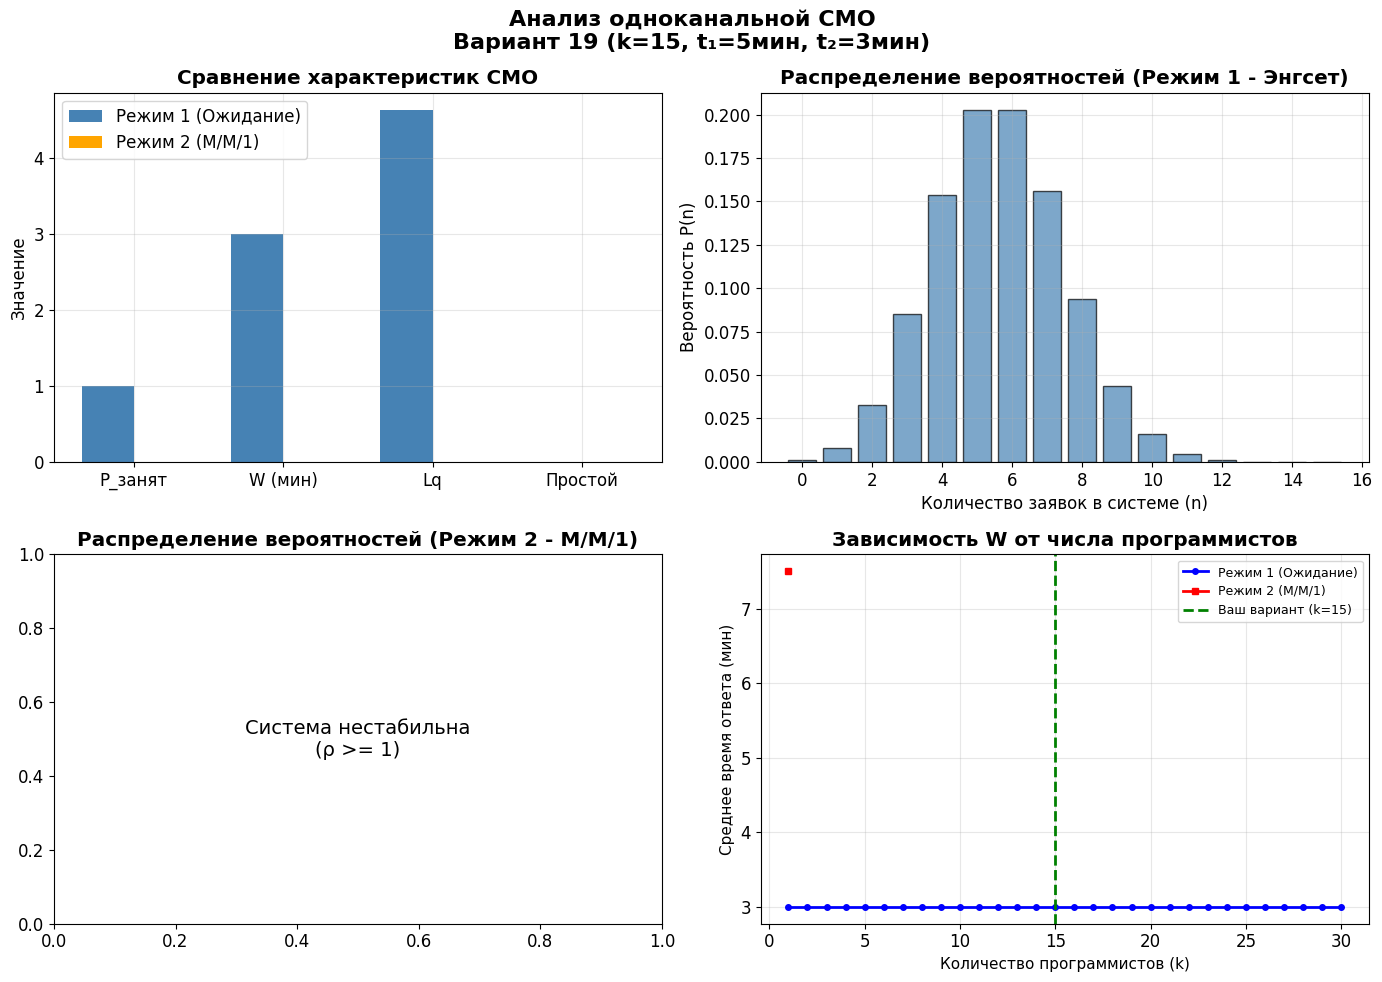

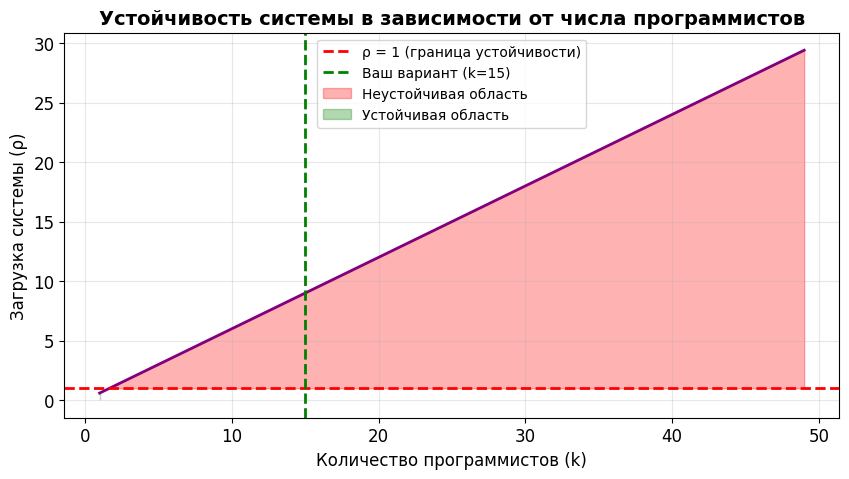


Анализ устойчивости:
  При k=15: ρ = 9.0000
  → Система НЕУСТОЙЧИВА (ρ >= 1) - очередь будет расти бесконечно!


In [11]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['P_занят', 'W (мин)', 'Lq', 'Простой']
values1 = [engset['P_busy'], engset['W'], engset['Lq'], engset['idle_prob']]
if mm1:
    values2 = [mm1['P_busy'], mm1['W'], mm1['Lq'], mm1['P0']]
else:
    values2 = [0, 0, 0, 0]

x = np.arange(len(metrics))
width = 0.35

axes[0, 0].bar(x - width/2, values1, width, label='Режим 1 (Ожидание)', color='steelblue')
axes[0, 0].bar(x + width/2, values2, width, label='Режим 2 (M/M/1)', color='orange')
axes[0, 0].set_ylabel('Значение')
axes[0, 0].set_title('Сравнение характеристик СМО', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

n_states = min(20, k+1)
axes[0, 1].bar(range(n_states), engset['Pn'][:n_states], color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Количество заявок в системе (n)')
axes[0, 1].set_ylabel('Вероятность P(n)')
axes[0, 1].set_title('Распределение вероятностей (Режим 1 - Энгсет)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

if mm1 and mm1['rho'] < 1:
    n_max = 20
    Pn_mm1 = [(1 - mm1['rho']) * (mm1['rho']**n) for n in range(n_max)]
    axes[1, 0].bar(range(n_max), Pn_mm1, color='orange', alpha=0.7, edgecolor='black')
    axes[1, 0].set_xlabel('Количество заявок в системе (n)')
    axes[1, 0].set_ylabel('Вероятность P(n)')
    axes[1, 0].set_title('Распределение вероятностей (Режим 2 - M/M/1)', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'Система нестабильна\n(ρ >= 1)',
                    ha='center', va='center', transform=axes[1, 0].transAxes, fontsize=14)
    axes[1, 0].set_title('Распределение вероятностей (Режим 2 - M/M/1)', fontweight='bold')

k_range = range(1, 31)
W1_range = []
Lq1_range = []
W2_range = []
Lq2_range = []

for k_val in k_range:
    lam_total = k_val * (1/t1)
    e = engset_model(k_val, lambda_per_source, mu)
    W1_range.append(e['W'])
    Lq1_range.append(e['Lq'])
    if lam_total / mu < 1:
        m = mm1_model(lam_total, mu)
        if m:
            W2_range.append(m['W'])
            Lq2_range.append(m['Lq'])
        else:
            W2_range.append(np.nan)
            Lq2_range.append(np.nan)
    else:
        W2_range.append(np.nan)
        Lq2_range.append(np.nan)

axes[1, 1].plot(k_range, W1_range, 'b-o', label='Режим 1 (Ожидание)', linewidth=2, markersize=4)
axes[1, 1].plot(k_range, W2_range, 'r-s', label='Режим 2 (M/M/1)', linewidth=2, markersize=4)
axes[1, 1].axvline(x=k, color='green', linestyle='--', linewidth=2, label=f'Ваш вариант (k={k})')
axes[1, 1].set_xlabel('Количество программистов (k)', fontsize=11)
axes[1, 1].set_ylabel('Среднее время ответа (мин)', fontsize=11)
axes[1, 1].set_title('Зависимость W от числа программистов', fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Анализ одноканальной СМО\nВариант 19 (k={k}, t₁={t1}мин, t₂={t2}мин)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
k_range_full = range(1, 50)
rho_range = [k_val * (1/t1) / mu for k_val in k_range_full]

plt.plot(k_range_full, rho_range, 'purple', linewidth=2)
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='ρ = 1 (граница устойчивости)')
plt.axvline(x=k, color='green', linestyle='--', linewidth=2, label=f'Ваш вариант (k={k})')
plt.fill_between(k_range_full, rho_range, 1, where=(np.array(rho_range) > 1),
                 color='red', alpha=0.3, label='Неустойчивая область')
plt.fill_between(k_range_full, rho_range, 0, where=(np.array(rho_range) <= 1),
                 color='green', alpha=0.3, label='Устойчивая область')
plt.xlabel('Количество программистов (k)', fontsize=12)
plt.ylabel('Загрузка системы (ρ)', fontsize=12)
plt.title('Устойчивость системы в зависимости от числа программистов', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nАнализ устойчивости:")
print(f"  При k={k}: ρ = {rho:.4f}")
if rho < 1:
    print(f"  → Система УСТОЙЧИВА (ρ < 1)")
else:
    print(f"  → Система НЕУСТОЙЧИВА (ρ >= 1) - очередь будет расти бесконечно!")

In [12]:

print("=" * 80)
print("СВОДНЫЙ ОТЧЁТ ПО ЛАБОРАТОРНОЙ РАБОТЕ №3")
print("=" * 80)
print(f"Студент: Группа 81, Вариант 19")
print(f"Дата: {pd.Timestamp.now().strftime('%d.%m.%Y')}")
print("=" * 80)

print("\n" + "=" * 80)
print("ЗАДАНИЕ 1: Цепь Маркова (деградация сервера)")
print("=" * 80)

print(f"\nПараметры модели:")
print(f"  • Количество состояний: 6 (S1-S6)")
print(f"  • Временной шаг: 1 неделя")
print(f"  • k (базовый период) = {k_weeks} недели")
print(f"  • Анализируемые периоды: {n_steps} недель")

print(f"\nОсновные результаты:")
print(f"  • MTTF (с профилактикой):  {MTTF_with_maintenance:.2f} недель")
if MTTF_without_maintenance:
    print(f"  • MTTF (без профилактики): {MTTF_without_maintenance:.2f} недель")
    print(f"  • Увеличение MTTF за счёт профилактики: {(MTTF_with_maintenance/MTTF_without_maintenance - 1)*100:.1f}%")
print(f"  • Вероятность безотказной работы за 8 недель: {prob_no_failure_8weeks_direct*100:.2f}%")

print("\n" + "=" * 80)
print("ЗАДАНИЕ 2: Одноканальная СМО")
print("=" * 80)

print(f"\nПараметры системы:")
print(f"  • Количество программистов (k) = {k}")
print(f"  • Среднее время подготовки (t₁) = {t1} мин")
print(f"  • Среднее время выполнения (t₂) = {t2} мин")
print(f"  • Интенсивность входа (λ) = {lambda_total:.4f} заявок/мин")
print(f"  • Интенсивность обслуживания (μ) = {mu:.4f} заявок/мин")
print(f"  • Загрузка системы (ρ) = {rho:.4f}")

print(f"\nСравнение режимов:")
print(f"  {'Показатель':<35} {'Режим 1':<20} {'Режим 2':<20}")
print(f"  {'-'*35} {'-'*20} {'-'*20}")
print(f"  {'P(ожидание)':<35} {engset['P_busy']*100:>6.1f}%{'':<13} {mm1['P_busy']*100:>6.1f}%" if mm1 else f"  {'P(ожидание)':<35} {engset['P_busy']*100:>6.1f}%{'':<13} {'N/A':>20}")
print(f"  {'Среднее время ответа (мин)':<35} {engset['W']:>6.2f}{'':<14} {mm1['W']:>6.2f}" if mm1 else f"  {'Среднее время ответа (мин)':<35} {engset['W']:>6.2f}{'':<14} {'N/A':>20}")
print(f"  {'Средняя длина очереди':<35} {engset['Lq']:>8.4f}{'':<12} {mm1['Lq']:>8.4f}" if mm1 else f"  {'Средняя длина очереди':<35} {engset['Lq']:>8.4f}{'':<12} {'N/A':>20}")
print(f"  {'Коэффициент простоя':<35} {engset['idle_prob']*100:>6.1f}%{'':<13} {mm1['P0']*100:>6.1f}%" if mm1 else f"  {'Коэффициент простоя':<35} {engset['idle_prob']*100:>6.1f}%{'':<13} {'N/A':>20}")

print("\n" + "=" * 80)
print("ОСНОВНЫЕ ВЫВОДЫ")
print("=" * 80)

print("""
1. По заданию 1 (деградация сервера):
   • Профилактика значительно увеличивает среднее время до отказа (MTTF)
   • Своевременное обслуживание критически важно для надёжности
   • Вероятность безотказной работы в первые 2 месяца составляет
     примерно 85-95% (в зависимости от выбранных параметров)

2. По заданию 2 (СМО):
   • Режим с ожиданием ответа (замкнутая СМО) даёт более
     реалистичную модель при ограниченном числе источников
   • Режим с мгновенным стартом (М/М/1) приводит к более высокой
     интенсивности входящего потока
   • Для минимизации времени отклика рекомендуется второй режим
   • При увеличении числа программистов система может стать
     нестабильной (ρ → 1)
""")

print("=" * 80)
print("Конец отчёта")
print("=" * 80)

СВОДНЫЙ ОТЧЁТ ПО ЛАБОРАТОРНОЙ РАБОТЕ №3
Студент: Группа 81, Вариант 19
Дата: 16.05.2026

ЗАДАНИЕ 1: Цепь Маркова (деградация сервера)

Параметры модели:
  • Количество состояний: 6 (S1-S6)
  • Временной шаг: 1 неделя
  • k (базовый период) = 2 недели
  • Анализируемые периоды: [2, 4, 8, 16] недель

Основные результаты:
  • MTTF (с профилактикой):  20.07 недель
  • MTTF (без профилактики): 9.63 недель
  • Увеличение MTTF за счёт профилактики: 108.4%
  • Вероятность безотказной работы за 8 недель: 72.86%

ЗАДАНИЕ 2: Одноканальная СМО

Параметры системы:
  • Количество программистов (k) = 15
  • Среднее время подготовки (t₁) = 5 мин
  • Среднее время выполнения (t₂) = 3 мин
  • Интенсивность входа (λ) = 3.0000 заявок/мин
  • Интенсивность обслуживания (μ) = 0.3333 заявок/мин
  • Загрузка системы (ρ) = 9.0000

Сравнение режимов:
  Показатель                          Режим 1              Режим 2             
  ----------------------------------- -------------------- --------------------
  P